<a href="https://colab.research.google.com/github/JoseAroudo/Compiladores/blob/main/MiniTcl_Gramatica_Semantica_y_Lexer_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MiniTcl 1.0: gramática, semántica y analizador léxico

**Curso:** Compiladores  
**Propósito:** convertir la implementación inicial de `lexer`, `parser` y `model` en una especificación verificable del lenguaje MiniTcl.

Al terminar este cuaderno, el estudiante podrá:

1. distinguir léxico, sintaxis y semántica;
2. leer una gramática BNF/EBNF;
3. reconocer la estructura de comandos de Tcl;
4. aplicar precedencia y asociatividad en `expr`;
5. implementar un lexer con posiciones y errores léxicos;
6. comprobar el lexer mediante pruebas automáticas.

> **Decisión de diseño.** MiniTcl 1.0 es un subconjunto educativo, no una implementación completa de Tcl. La especificación de este cuaderno es el contrato que deben seguir el lexer, el parser y el intérprete.

In [ ]:
from dataclasses import dataclass
from typing import Any

print("Cuaderno MiniTcl 1.0 listo")

Cuaderno MiniTcl 1.0 listo


## 1. Tres niveles del lenguaje

| Nivel | Pregunta | Ejemplo |
|---|---|---|
| Léxico | ¿Qué secuencias forman tokens? | `$total` → `VAR(total)` |
| Sintáctico | ¿Cómo se combinan los tokens? | `set total 10` → comando de tres palabras |
| Semántico | ¿Qué significa y cuándo es válido? | `set` exige 2 o 3 palabras |

La tubería prevista es:

$$
\text{fuente}\;\longrightarrow\;\text{lexer}\;\longrightarrow\;\text{tokens}
\;\longrightarrow\;\text{parser}\;\longrightarrow\;\text{AST}
\;\longrightarrow\;\text{intérprete}
$$

Un parser genérico de Tcl reconoce *comandos y palabras*. Después, el intérprete valida la forma particular de `set`, `if`, `while`, etc.

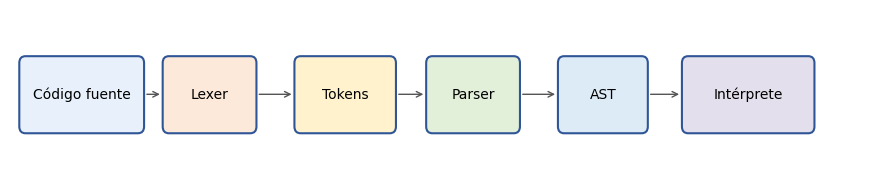

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 2)
ax.axis("off")

etapas = ["Código fuente", "Lexer", "Tokens", "Parser", "AST", "Intérprete"]
xs = [0.2, 2.05, 3.75, 5.45, 7.15, 8.75]
anchos = [1.45, 1.05, 1.15, 1.05, 1.0, 1.55]
colores = ["#E8F1FB", "#FDE9D9", "#FFF2CC", "#E2F0D9", "#DDEBF7", "#E4DFEC"]

for i, (x, w, etiqueta, color) in enumerate(zip(xs, anchos, etapas, colores)):
    ax.add_patch(FancyBboxPatch((x, .62), w, .75, boxstyle="round,pad=0.08",
                                facecolor=color, edgecolor="#2F5597", linewidth=1.5))
    ax.text(x + w/2, 1, etiqueta, ha="center", va="center", fontsize=10)
    if i < len(etapas) - 1:
        ax.annotate("", xy=(xs[i+1]-.08, 1), xytext=(x+w+.08, 1),
                    arrowprops=dict(arrowstyle="->", color="#555"))
plt.show()

## 2. Alcance semántico de MiniTcl 1.0

### 2.1 Valores

Todo valor almacenado por MiniTcl es una cadena. `expr` convierte temporalmente operandos a número o booleano y devuelve su resultado como cadena.

- Enteros: `0`, `25`, `-7`.
- Reales: `3.14`, `.5`, `2e3`.
- Booleanos verdaderos: `1`, `true`, `yes`, `on`.
- Booleanos falsos: `0`, `false`, `no`, `off`.
- Listas: secuencias de palabras; en esta versión no se implementan las reglas completas de listas Tcl.

### 2.2 Comandos obligatorios

| Forma | Resultado / efecto | Restricción semántica |
|---|---|---|
| `set nombre` | consulta una variable | debe existir |
| `set nombre valor` | asigna y devuelve `valor` | nombre válido |
| `puts valor` | escribe con salto de línea | exactamente un valor |
| `puts -nonewline valor` | escribe sin salto | opción exacta |
| `expr expresión` | evalúa una expresión | tipos y operadores válidos |
| `if prueba cuerpo ...` | selección | prueba convertible a booleano |
| `while prueba cuerpo` | repetición | `break`/`continue` solo dentro del ciclo |
| `incr nombre ?cantidad?` | incrementa variable | operandos enteros; cantidad por defecto 1 |
| `proc nombre parámetros cuerpo` | define procedimiento | parámetros no repetidos |
| `return ?valor?` | retorna | solo dentro de procedimiento |
| `break` | termina ciclo | solo dentro de ciclo |
| `continue` | siguiente iteración | solo dentro de ciclo |

Las llamadas cuyo primer término no sea un comando incorporado buscan un procedimiento definido con `proc`.

## 3. Gramática estructural del script

### 3.1 EBNF legible

```ebnf
script       = { separador }, [ comando,
                 { separador, { separador }, comando } ], { separador } ;
comando      = palabra, { palabra } ;
separador    = NEWLINE | ";" ;

palabra      = simple | variable | variable_arreglo
             | bloque | cadena | sustitucion_comando ;
simple       = NAME | TEXT ;
variable     = VAR ;
variable_arreglo = ARRAY_VAR ;
bloque       = BRACED ;
cadena       = STRING ;
sustitucion_comando = COMMAND_SUBST ;
```

### 3.2 BNF estricta

```bnf
<script> ::= <separadores-opt> <comandos-opt> <separadores-opt>
<comandos-opt> ::= ε | <lista-comandos>
<lista-comandos> ::= <comando> | <comando> <separadores> <lista-comandos>
<comando> ::= <palabra> | <palabra> <comando>
<palabra> ::= NAME | TEXT | VAR | ARRAY_VAR | BRACED | STRING | COMMAND_SUBST
<separadores-opt> ::= ε | <separadores>
<separadores> ::= <separador> | <separador> <separadores>
<separador> ::= NEWLINE | SEMI
```

`BRACED`, `STRING` y `COMMAND_SUBST` son tokens balanceados producidos por el lexer. El contenido de `COMMAND_SUBST` se vuelve a analizar como `<script>`.

## 4. Formas sintácticas y restricciones semánticas

La gramática estructural permite cualquier secuencia de palabras. Las siguientes producciones describen la forma que debe validar el intérprete:

```bnf
<comando-semantico> ::= <set> | <puts> | <expr-cmd> | <if>
                     | <while> | <incr> | <proc> | <return>
                     | <break> | <continue> | <llamada>

<set> ::= "set" <nombre-var>
        | "set" <nombre-var> <valor>

<puts> ::= "puts" <valor>
         | "puts" "-nonewline" <valor>

<expr-cmd> ::= "expr" <expresion>

<if> ::= "if" <expresion> <bloque-script> <cola-if>
<cola-if> ::= ε
            | "else" <bloque-script>
            | "elseif" <expresion> <bloque-script> <cola-if>

<while> ::= "while" <expresion> <bloque-script>

<incr> ::= "incr" <nombre-var>
         | "incr" <nombre-var> <entero>

<proc> ::= "proc" <nombre> <lista-parametros> <bloque-script>
<lista-parametros> ::= "{" <parametros-opt> "}"
<parametros-opt> ::= ε | <nombre> | <nombre> <parametros-opt>

<return> ::= "return" | "return" <valor>
<break> ::= "break"
<continue> ::= "continue"

<llamada> ::= <nombre-procedimiento> <argumentos-opt>
<argumentos-opt> ::= ε | <valor> <argumentos-opt>
```

`then` después de la condición es opcional y se considera azúcar sintáctico. Cada cuerpo de `if`, `while` o `proc` debe llegar como una palabra entre llaves.

## 5. Sustitución y evaluación

Antes de ejecutar un comando se procesan sus palabras de izquierda a derecha:

| Forma | Sustituciones |
|---|---|
| `{ ... }` | ninguna; conserva el contenido literal |
| `" ... "` | variables, comandos y escapes |
| palabra sin comillas | variables, comandos y escapes |
| `$x` | valor de la variable `x` |
| `$a(i)` | elemento `i` del arreglo `a` |
| `[ ... ]` | resultado de ejecutar el script interno |

En MiniTcl 1.0 no hay expansión de argumentos mediante `{*}`. Los bloques se conservan sin sustitución hasta que un comando como `if`, `while` o `proc` decide evaluarlos.

### Reglas de estado

Usaremos el juicio $\langle c,\sigma\rangle\Downarrow\langle v,\sigma'\rangle$, donde $\sigma$ es el entorno de variables.

```text
SET-ASIGNA
eval(valor, σ) = v
────────────────────────────────────────
⟨set x valor, σ⟩ ⇓ ⟨v, σ[x ↦ v]⟩

SET-CONSULTA
x ∈ dom(σ)
────────────────────────────────────────
⟨set x, σ⟩ ⇓ ⟨σ(x), σ⟩

IF-TRUE
eval_expr(prueba, σ) = true     ⟨cuerpo, σ⟩ ⇓ ⟨v, σ'⟩
────────────────────────────────────────────────────────
⟨if prueba cuerpo, σ⟩ ⇓ ⟨v, σ'⟩

IF-FALSE
eval_expr(prueba, σ) = false
────────────────────────────────────────
⟨if prueba cuerpo, σ⟩ ⇓ ⟨"", σ⟩
```

`&&` y `||` usan cortocircuito. Una división por cero, una variable inexistente, una aridad incorrecta o una conversión imposible producen un error del intérprete, no un error léxico.

## 6. Gramática completa de `expr`

La precedencia aumenta al descender en la gramática. `||`, `&&`, comparaciones, suma y multiplicación son asociativos a la izquierda; `**` es asociativo a la derecha.

```bnf
<expresion> ::= <or>

<or> ::= <and> | <or> "||" <and>
<and> ::= <igualdad> | <and> "&&" <igualdad>

<igualdad> ::= <relacional>
             | <igualdad> "==" <relacional>
             | <igualdad> "!=" <relacional>

<relacional> ::= <aditiva>
               | <relacional> "<"  <aditiva>
               | <relacional> "<=" <aditiva>
               | <relacional> ">"  <aditiva>
               | <relacional> ">=" <aditiva>

<aditiva> ::= <multiplicativa>
            | <aditiva> "+" <multiplicativa>
            | <aditiva> "-" <multiplicativa>

<multiplicativa> ::= <unaria>
                   | <multiplicativa> "*" <unaria>
                   | <multiplicativa> "/" <unaria>
                   | <multiplicativa> "%" <unaria>

<unaria> ::= <potencia>
           | "+" <unaria>
           | "-" <unaria>
           | "!" <unaria>

<potencia> ::= <primaria>
             | <primaria> "**" <unaria>

<primaria> ::= NUMBER | VAR | TRUE | FALSE
             | "(" <expresion> ")"
```

Ejemplos:

- `2 + 3 * 4` se interpreta como `2 + (3 * 4)`.
- `2 ** 3 ** 2` se interpreta como `2 ** (3 ** 2)`.
- `-2 ** 2` se interpreta como `-(2 ** 2)`.
- `$x != 0 && 10 / $x > 1` no divide por cero cuando `$x == 0`.

## 7. Semántica de operadores de `expr`

| Operador | Tipo de entrada | Resultado | Error |
|---|---|---|---|
| `+ - * **` | números | número | operando no numérico |
| `/` | números | real | división por cero |
| `%` | enteros | entero | módulo por cero/no entero |
| `< <= > >=` | números | booleano `0/1` | operando no numérico |
| `== !=` | dos números o dos cadenas | booleano `0/1` | — |
| `!` | booleano convertible | booleano `0/1` | valor no booleano |
| `&& ||` | booleanos convertibles | booleano `0/1` | valor no booleano |

La igualdad es numérica cuando ambos operandos se convierten a número; en otro caso es una comparación textual. Los booleanos se normalizan a `1` y `0`.

## 8. Contrato del analizador léxico

El lexer principal debe producir estos tokens:

| Token | Ejemplo | Valor guardado |
|---|---|---|
| `NAME` | `set`, `total_1` | texto |
| `TEXT` | `-nonewline`, `3.14` | texto |
| `VAR` | `$total` | nombre sin `$` |
| `ARRAY_VAR` | `$datos(3)` | `(nombre, índice)` |
| `BRACED` | `{set x 1}` | contenido sin llaves |
| `STRING` | `"hola $x"` | contenido sin comillas |
| `COMMAND_SUBST` | `[expr {$x+1}]` | contenido sin corchetes |
| `NEWLINE` | uno o más saltos | texto de los saltos |
| `SEMI` | `;` | `;` |

### Prioridad de reconocimiento

1. espacios horizontales;
2. saltos de línea;
3. `;`;
4. comentarios `#...`;
5. bloques balanceados `{...}`;
6. comandos balanceados `[...]`;
7. cadenas `"..."`;
8. variables `$x` y `$a(i)`;
9. palabras `NAME`/`TEXT`;
10. error.

Para mantener compatibilidad con el lexer inicial, `#` inicia un comentario siempre que aparece fuera de llaves, corchetes o comillas. Esto es una simplificación deliberada respecto de Tcl completo.

## 9. Enunciado: lexer que debe realizar el estudiante

Implemente `MiniTclLexer.tokenize(source)` sin utilizar generadores de analizadores léxicos. Puede usar expresiones regulares para nombres y números, pero los delimitadores balanceados deben recorrerse carácter a carácter.

### Requisitos funcionales

1. Registrar línea, columna e índice absoluto de cada token.
2. Ignorar espacio, tabulador y retorno de carro.
3. Agrupar saltos consecutivos en un `NEWLINE`.
4. ignorar comentarios hasta el salto de línea, conservando el `NEWLINE` posterior;
5. admitir anidamiento de `{...}` y `[...]`;
6. no cerrar un grupo cuando el delimitador esté escapado;
7. conservar los escapes como dos caracteres para una fase posterior;
8. reconocer identificadores con `[A-Za-z_][A-Za-z0-9_]*`;
9. informar delimitadores sin cerrar y variables mal formadas;
10. finalizar sin token `EOF`, para ser compatible con el parser entregado.

> **Separación de responsabilidades:** el lexer de MiniTcl no tokeniza los operadores dentro de `{...}`. El comando `expr` entrega ese contenido a un segundo lexer especializado.

In [ ]:
@dataclass(frozen=True)
class Token:
    type: str
    value: Any
    lineno: int
    column: int
    index: int


class TclLexError(Exception):
    pass


class MiniTclLexerEstudiante:
    # Plantilla de trabajo. Complete todos los TODO.

    def tokenize(self, source: str) -> list[Token]:
        self.source = source
        self.i = 0
        self.line = 1
        self.column = 1
        self.tokens = []

        # TODO: recorrido principal según la tabla de prioridad.
        raise NotImplementedError("Implemente tokenize")

    def read_balanced(self, opening: str, closing: str, token_type: str):
        # TODO: profundidad, escapes y actualización de posición.
        raise NotImplementedError

    def read_string(self):
        # TODO: leer hasta comilla no escapada.
        raise NotImplementedError

    def read_variable(self):
        # TODO: VAR y ARRAY_VAR.
        raise NotImplementedError

    def read_word(self):
        # TODO: distinguir NAME de TEXT.
        raise NotImplementedError

## 10. Casos de prueba obligatorios

Antes de programar, prediga los tokens. Después compare la predicción con su lexer.

```tcl
set x 10
puts "x = $x"
puts [expr {$x + 20}]
set datos(nombre) Angel
```

La secuencia de tipos esperada es:

```text
NAME NAME TEXT NEWLINE
NAME STRING NEWLINE
NAME COMMAND_SUBST NEWLINE
NAME TEXT NAME
```

Los contenidos de la cadena y del comando sustituido permanecen sin tokenizar en esta fase.
`datos(nombre)` es `TEXT` porque allí es el nombre de destino de `set`; la lectura
`$datos(nombre)` sí produce `ARRAY_VAR`.

In [ ]:
CASOS_LEXER = [
    ("set x 10", ["NAME", "NAME", "TEXT"]),
    ("puts \"x = $x\"", ["NAME", "STRING"]),
    ("puts [expr {$x + 20}]", ["NAME", "COMMAND_SUBST"]),
    ("set datos(nombre) Angel", ["NAME", "TEXT", "NAME"]),
    ("set x 1; incr x", ["NAME", "NAME", "TEXT", "SEMI", "NAME", "NAME"]),
    ("# comentario\nputs ok", ["NEWLINE", "NAME", "NAME"]),
    ("if {$x > 0} {puts {positivo}}", ["NAME", "BRACED", "BRACED"]),
]


def verificar_lexer(lexer_cls):
    for fuente, esperados in CASOS_LEXER:
        obtenidos = [t.type for t in lexer_cls().tokenize(fuente)]
        assert obtenidos == esperados, (fuente, esperados, obtenidos)
    print(f"✓ {len(CASOS_LEXER)} pruebas superadas")


print("Casos de prueba preparados; ejecute verificar_lexer(SuLexer).")

## 11. Lexer independiente para `expr`

Cuando el intérprete ejecuta `expr {$x + 2 * 3}`, toma el contenido del token `BRACED` y aplica un lexer diferente.

Tokens requeridos:

```text
NUMBER VAR TRUE FALSE
PLUS MINUS STAR SLASH PERCENT POWER
EQ NE LT LE GT GE AND OR NOT
LPAREN RPAREN
```

Los operadores de dos caracteres deben reconocerse antes que los de uno: `**`, `==`, `!=`, `<=`, `>=`, `&&`, `||`.

In [ ]:
import re

EXPR_TOKEN_SPEC = [
    ("SPACE",   r"[ \t\r\n]+"),
    ("NUMBER",  r"(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"),
    ("VAR",     r"\$[A-Za-z_][A-Za-z0-9_]*"),
    ("POWER",   r"\*\*"),
    ("EQ",      r"=="), ("NE", r"!="),
    ("LE",      r"<="), ("GE", r">="),
    ("AND",     r"&&"), ("OR", r"\|\|"),
    ("PLUS",    r"\+"), ("MINUS", r"-"),
    ("STAR",    r"\*"), ("SLASH", r"/"), ("PERCENT", r"%"),
    ("LT",      r"<"), ("GT", r">"), ("NOT", r"!"),
    ("LPAREN",  r"\("), ("RPAREN", r"\)"),
    ("BOOLEAN", r"[A-Za-z_][A-Za-z0-9_]*"),
]

EXPR_MASTER = re.compile("|".join(f"(?P<{name}>{pattern})"
                                  for name, pattern in EXPR_TOKEN_SPEC))


def expr_tokenize(source: str):
    # Solución de referencia para el lexer pequeño de expr.
    pos = 0
    result = []
    while pos < len(source):
        match = EXPR_MASTER.match(source, pos)
        if not match:
            raise TclLexError(f"Carácter inválido en expr: {source[pos]!r}, posición {pos}")
        kind, value = match.lastgroup, match.group()
        pos = match.end()
        if kind == "SPACE":
            continue
        if kind == "BOOLEAN":
            low = value.lower()
            if low not in {"true", "false", "yes", "no", "on", "off"}:
                raise TclLexError(f"Nombre no válido en expr: {value!r}")
            kind = "TRUE" if low in {"true", "yes", "on"} else "FALSE"
        result.append((kind, value))
    return result


expr_tokenize("$x != 0 && 10 / $x > 1")

## 12. Solución docente de referencia para el lexer principal

La siguiente celda está marcada con la etiqueta `solution`. Para entregar el taller al estudiante puede ocultarse o eliminarse. La solución sigue exactamente el contrato del apartado 8.

In [ ]:
import re


class MiniTclLexer:
    NAME_RE = re.compile(r"[A-Za-z_][A-Za-z0-9_]*\Z")
    ID_START_RE = re.compile(r"[A-Za-z_]")
    ID_CONT_RE = re.compile(r"[A-Za-z0-9_]")
    WORD_STOPS = set(";{}[]\"$")

    def tokenize(self, source: str) -> list[Token]:
        self.source = source
        self.i = 0
        self.line = 1
        self.column = 1
        self.tokens = []

        while self.i < len(self.source):
            ch = self.source[self.i]
            if ch in " \t\r":
                self._consume(ch)
            elif ch == "\n":
                self._read_newlines()
            elif ch == ";":
                self._emit_single("SEMI")
            elif ch == "#":
                self._read_comment()
            elif ch == "{":
                self._read_balanced("{", "}", "BRACED")
            elif ch == "[":
                self._read_balanced("[", "]", "COMMAND_SUBST")
            elif ch == '"':
                self._read_string()
            elif ch == "$":
                self._read_variable()
            else:
                self._read_word()
        return self.tokens

    def _mark(self):
        return self.i, self.line, self.column

    def _consume(self, text: str):
        for ch in text:
            self.i += 1
            if ch == "\n":
                self.line += 1
                self.column = 1
            else:
                self.column += 1

    def _append(self, kind, value, mark):
        index, line, column = mark
        self.tokens.append(Token(kind, value, line, column, index))

    def _emit_single(self, kind):
        mark = self._mark()
        value = self.source[self.i]
        self._consume(value)
        self._append(kind, value, mark)

    def _read_newlines(self):
        mark = self._mark()
        start = self.i
        while self.i < len(self.source) and self.source[self.i] == "\n":
            self._consume("\n")
        self._append("NEWLINE", self.source[start:self.i], mark)

    def _read_comment(self):
        while self.i < len(self.source) and self.source[self.i] != "\n":
            self._consume(self.source[self.i])

    def _read_balanced(self, opening, closing, kind):
        mark = self._mark()
        self._consume(opening)
        depth = 1
        chars = []
        while self.i < len(self.source):
            ch = self.source[self.i]
            if ch == "\\" and self.i + 1 < len(self.source):
                pair = self.source[self.i:self.i + 2]
                chars.append(pair)
                self._consume(pair)
            elif ch == opening:
                depth += 1
                chars.append(ch)
                self._consume(ch)
            elif ch == closing:
                depth -= 1
                if depth == 0:
                    self._consume(ch)
                    self._append(kind, "".join(chars), mark)
                    return
                chars.append(ch)
                self._consume(ch)
            else:
                chars.append(ch)
                self._consume(ch)
        raise TclLexError(f"{opening!r} sin cerrar en línea {mark[1]}, columna {mark[2]}")

    def _read_string(self):
        mark = self._mark()
        self._consume('"')
        chars = []
        while self.i < len(self.source):
            ch = self.source[self.i]
            if ch == "\\" and self.i + 1 < len(self.source):
                pair = self.source[self.i:self.i + 2]
                chars.append(pair)
                self._consume(pair)
            elif ch == '"':
                self._consume(ch)
                self._append("STRING", "".join(chars), mark)
                return
            else:
                chars.append(ch)
                self._consume(ch)
        raise TclLexError(f"Comilla sin cerrar en línea {mark[1]}, columna {mark[2]}")

    def _read_variable(self):
        mark = self._mark()
        self._consume("$")
        if self.i >= len(self.source) or not self.ID_START_RE.fullmatch(self.source[self.i]):
            raise TclLexError(f"Variable mal formada en línea {mark[1]}, columna {mark[2]}")
        start = self.i
        while self.i < len(self.source) and self.ID_CONT_RE.fullmatch(self.source[self.i]):
            self._consume(self.source[self.i])
        name = self.source[start:self.i]
        if self.i < len(self.source) and self.source[self.i] == "(":
            self._consume("(")
            idx_start = self.i
            while self.i < len(self.source) and self.source[self.i] != ")":
                self._consume(self.source[self.i])
            if self.i >= len(self.source):
                raise TclLexError(f"Índice de arreglo sin cerrar en línea {mark[1]}")
            index = self.source[idx_start:self.i]
            self._consume(")")
            self._append("ARRAY_VAR", (name, index), mark)
        else:
            self._append("VAR", name, mark)

    def _read_word(self):
        mark = self._mark()
        start = self.i
        while self.i < len(self.source):
            ch = self.source[self.i]
            if ch.isspace() or ch in self.WORD_STOPS:
                break
            self._consume(ch)
        if self.i == start:
            raise TclLexError(f"Carácter inesperado {self.source[self.i]!r} en línea {self.line}")
        value = self.source[start:self.i]
        kind = "NAME" if self.NAME_RE.fullmatch(value) else "TEXT"
        self._append(kind, value, mark)


verificar_lexer(MiniTclLexer)

## 13. Pruebas de errores y balanceo

Un buen lexer no solo acepta programas válidos: debe rechazar entradas incompletas con una posición útil.

In [ ]:
def debe_fallar(source):
    try:
        MiniTclLexer().tokenize(source)
    except TclLexError as error:
        print("✓", repr(source), "→", error)
        return
    raise AssertionError(f"Se esperaba TclLexError para {source!r}")


debe_fallar('puts "sin cerrar')
debe_fallar('if {$x > 0 {puts ok}')
debe_fallar('puts [expr {$x + 1}')
debe_fallar('set x $')

anidado = MiniTclLexer().tokenize('if {$x} {if {$y} {puts ok}}')
assert [t.type for t in anidado] == ["NAME", "BRACED", "BRACED"]
print("✓ balanceo anidado")

## 14. Ejercicios

### Ejercicio 1 — Clasificación manual

Produzca los tokens, valores y posiciones para:

```tcl
set radio 2.5
set area [expr {3.1416 * $radio ** 2}]
puts "Área = $area"
```

### Ejercicio 2 — Autómata para identificadores

Construya el DFA de `[A-Za-z_][A-Za-z0-9_]*`. Indique estado inicial, estado de aceptación y transición al estado muerto.

### Ejercicio 3 — Extender las pruebas

Agregue por lo menos cinco casos: cadena multilínea, llave escapada, arreglo, comentario y dos comandos separados por `;`.

### Ejercicio 4 — Lexer de `expr`

Implemente su propia versión de `expr_tokenize` y pruebe:

```text
-2 ** 2
($x + 3.5) * 2
$x != 0 && 10 / $x > 1
true || false && false
```

### Ejercicio 5 — Del lexer al parser

Adapte el parser proporcionado al nuevo `Token`, que ahora incluye `column`. Compruebe que la sustitución `[expr {...}]` construye recursivamente un `Script`.

### Desafío

El lexer inicial separa `hola$x` en dos palabras. Diseñe un token o una fase de agrupación que permita construir una sola `Word` con `TextPart("hola")` y `VarPart("x")`. Explique qué cambios requiere el parser.

## 15. Rúbrica sugerida

| Criterio | Porcentaje |
|---|---:|
| Tokens básicos y posiciones | 20 % |
| Variables y arreglos | 15 % |
| Llaves/corchetes balanceados | 20 % |
| Cadenas, escapes y comentarios | 15 % |
| Manejo de errores | 10 % |
| Lexer de `expr` | 10 % |
| Pruebas y calidad del código | 10 % |

## Lista de comprobación

- [ ] No confundir error léxico con error sintáctico o semántico.
- [ ] Reconocer operadores largos antes que los cortos.
- [ ] Actualizar línea y columna dentro de cadenas y bloques.
- [ ] Conservar el contenido interno sin delimitadores.
- [ ] Verificar balanceo y escapes.
- [ ] Ejecutar todas las pruebas antes de entregar.

## 16. Cierre

La idea esencial de MiniTcl es que la sintaxis externa es pequeña: un script contiene comandos y un comando contiene palabras. La riqueza aparece después, cuando las sustituciones producen valores y el primer término selecciona la semántica del comando.

La implementación puede avanzar en tres hitos:

1. **Lexer principal:** tokens estructurales y posiciones.
2. **Parser MiniTcl:** `Script → Command → Word → Part`.
3. **`expr`:** lexer, parser con precedencia y evaluación del AST.